This notebook is my implemenation of the option-critic architecture.

It follows the 2017 paper on the same (Bacon et. al.)

plan:
1. neural network with two heads rep. intra option policies and termination functions.
2. a separate neural network that predicts the critic output.
3. train it one the four rooms architecture and try to get some good options.
4. uses weights and biases (personal api) to visualize training metrics.

In [2]:
# Imports 

import os
import numpy as np
import matplotlib
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm 
import random
import torch
import torch.nn as nn 
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import gymnasium as gym
from gymnasium import spaces
import wandb
wandb.login()

True

Here we initialize the four rooms environment. its a 11x11 grid that has 4 doorways a fixed goal at the top right corner (0,10)

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch

class FourRoomsEnv(gym.Env):
    def __init__(self, bottleneck_rewards=False):
        super(FourRoomsEnv, self).__init__()
        
        self.grid_size = 11
        self.max_steps = 200
        self.bottleneck_rewards = bottleneck_rewards
        
        self.action_space = spaces.Discrete(4)
        
        #observation is a 6D vector: [r, c, door1_status, door2_status, door3_status, door4_status]
        self.observation_space = spaces.Box(low=0.0, high=float(self.grid_size), shape=(6,), dtype=np.float32)
        
        self.goal_state = (0, 10)
        self.walls = set()
        
        for i in range(self.grid_size):
            self.walls.add((5, i))
            self.walls.add((i, 5))
            
        #doorway list
        self.doorway_list = [(5, 1), (5, 8), (2, 5), (9, 5)]
        
        for door in self.doorway_list:
            self.walls.remove(door)
        
        self.valid_states = []
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                if (r, c) not in self.walls and (r, c) != self.goal_state:
                    self.valid_states.append((r, c))
                    
        self.current_state = None
        self.current_step = 0
        self.visited_doorways = set()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        self.current_step = 0
        self.visited_doorways.clear()
        
        idx = self.np_random.integers(0, len(self.valid_states))
        self.current_state = self.valid_states[idx]
        
        return self._get_obs(), {}

    def step(self, action):
       
        if isinstance(action, torch.Tensor):
            action = action.item()
        else:
            action = int(action)

        self.current_step += 1
        r, c = self.current_state
        
        if action == 0:   r -= 1
        elif action == 1: c += 1
        elif action == 2: r += 1
        elif action == 3: c -= 1
            
        if 0 <= r < self.grid_size and 0 <= c < self.grid_size:
            if (r, c) not in self.walls:
                self.current_state = (r, c)
                
        terminated = (self.current_state == self.goal_state)
        truncated = (self.current_step >= self.max_steps)
        
        reward = 10.0 if terminated else 0.0

        #bottleneck rewards.
        if self.bottleneck_rewards:
            if self.current_state in self.doorway_list and self.current_state not in self.visited_doorways:
                reward += 0.5
                self.visited_doorways.add(self.current_state)
        
        return self._get_obs(), reward, terminated, truncated, {}

    def _get_obs(self):
        #constructs the fully observable state
        r, c = self.current_state
        obs = [float(r), float(c)]
        
        for door in self.doorway_list:
            obs.append(1.0 if door in self.visited_doorways else 0.0)
            
        return np.array(obs, dtype=np.float32)

check the render for our environment.

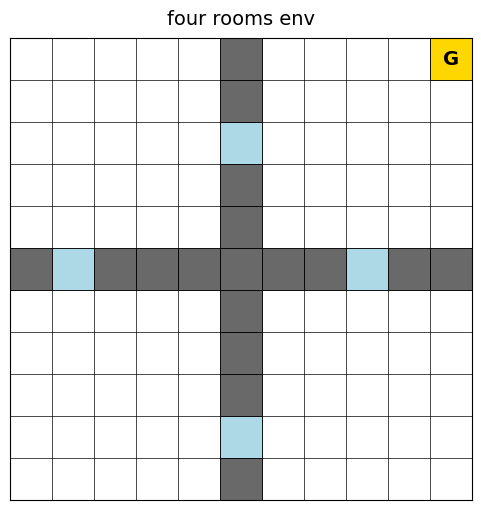

In [21]:
def render_env(env):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Set axis limits
    ax.set_xlim(0, env.grid_size)
    ax.set_ylim(0, env.grid_size)
    
    # Invert the Y-axis so row 0 is at the top (standard matrix/gridworld layout)
    ax.invert_yaxis()
    
    # Draw the grid lines
    ax.set_xticks(np.arange(0, env.grid_size + 1, 1))
    ax.set_yticks(np.arange(0, env.grid_size + 1, 1))
    ax.grid(color='black', linestyle='-', linewidth=0.5)
    ax.set_aspect('equal') 
    
    # 1. Plot the Walls (Dark Gray)
    for (r, c) in env.walls:
        # Note: Matplotlib patches take (x, y) which corresponds to (column, row)
        rect = patches.Rectangle((c, r), 1, 1, facecolor='dimgray', edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)
        
    # 2. Plot the Doorways (Light Blue)
    if hasattr(env, 'doorway_list'):
        for (r, c) in env.doorway_list:
            rect = patches.Rectangle((c, r), 1, 1, facecolor='lightblue', edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)
            
    # 3. Plot the Goal State (Gold)
    if hasattr(env, 'goal_state'):
        gr, gc = env.goal_state
        rect = patches.Rectangle((gc, gr), 1, 1, facecolor='gold', edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)
        ax.text(gc + 0.5, gr + 0.5, 'G', color='black', weight='bold', ha='center', va='center', fontsize=14)

    
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(left=False, bottom=False)
    
    plt.title("four rooms env", fontsize=14, pad=10)
    plt.show()


env = FourRoomsEnv(bottleneck_rewards=True)
render_env(env)

Here we implement the critic network, takes a 2d vector (coords) as input and outputs a 4d vector (actions)

In [ ]:
class CriticNetwork(nn.Module):
    def __init__(self, num_options, grid_size=11):
        super(CriticNetwork, self).__init__()
        self.num_options = num_options
        self.grid_size = grid_size
        self.embedding = nn.Embedding(grid_size * grid_size, 32)
        
        #2 layer MLP
        self.network = nn.Sequential(
            nn.Linear(32 + 4, 64),  # 32 (spatial) + 4 (doorway statuses)
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, num_options)
        )

    def forward(self, state):

        r = state[:, 0]
        c = state[:, 1]
        state_idx = (r * self.grid_size + c).long()
        
        spatial_emb = self.embedding(state_idx)
        
        doorways = state[:, 2:]

        x = torch.cat([spatial_emb, doorways], dim=-1)
        return self.network(x)

Now we implement this actor network with two heads. 

In [ ]:
class ActorNetwork(nn.Module):
    def __init__(self, num_actions, num_options, grid_size=11):
        super(ActorNetwork, self).__init__()
        self.num_actions = num_actions
        self.num_options = num_options
        self.grid_size = grid_size
        
        
        self.embedding = nn.Embedding(grid_size * grid_size, 32)
        
        #shared 2 layer MLP
        self.backbone = nn.Sequential(
            nn.Linear(32 + 4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )
        
        self.policy_head = nn.Linear(64, num_options * num_actions)
        self.termination_head = nn.Linear(64, num_options)

    def forward(self, state):
        r = state[:, 0]
        c = state[:, 1]
        state_idx = (r * self.grid_size + c).long()
        
        spatial_emb = self.embedding(state_idx)
        doorways = state[:, 2:]
        
        x = torch.cat([spatial_emb, doorways], dim=-1)
        features = self.backbone(x)
        
        #intra option policy head
        policy_logits = self.policy_head(features)
        policy_logits = policy_logits.view(-1, self.num_options, self.num_actions)
        action_probs = F.softmax(policy_logits, dim=-1)
        
        #termination head
        termination_probs = torch.sigmoid(self.termination_head(features))
        
        return action_probs, termination_probs

here we calculate all the variables required by the agent.

In [ ]:
import torch

class OptionCriticMath:
    
    @staticmethod
    def get_state_value(q_Omega):
        """
        Calculates the State Value Function over options.
        Formula: V(s) = max_w Q(s, w)
        
        Args:
            q_Omega: Tensor of shape (batch_size, num_options). The critic's Q-values.
            
        Returns:
            v_state: Tensor of shape (batch_size,). 
        """
        return torch.max(q_Omega, dim=-1)[0]

    @staticmethod
    def get_arrival_value(q_Omega_next, v_state_next, beta_next, current_option):
        """
        Calculates the Option Value upon Arrival.
        Formula: U(s', w) = (1 - beta(s', w)) * Q(s', w) + beta(s', w) * V(s')
        
        Args:
            q_Omega_next: Tensor of shape (batch_size, num_options). 
            v_state_next: Tensor of shape (batch_size,).
            beta_next: Tensor of shape (batch_size, num_options). The termination probabilities.
            current_option: LongTensor of shape (batch_size,) indicating the active option.
            
        Returns:
            u_value: Tensor of shape (batch_size,).
        """
        batch_size = q_Omega_next.size(0)
        batch_idx = torch.arange(batch_size)
        
        # Isolate the Q-value and Termination prob for the specific option being executed
        q_w_next = q_Omega_next[batch_idx, current_option]
        beta_w_next = beta_next[batch_idx, current_option]
        
        return (1.0 - beta_w_next) * q_w_next + beta_w_next * v_state_next

    @staticmethod
    def get_action_value_in_context(reward, gamma, u_value, done):
        """
        Calculates the 1-step TD target for the Critic.
        Formula: Q_U(s, w, a) = r + gamma * (1 - done) * U(s', w)
        
        Args:
            reward: Tensor of shape (batch_size,).
            gamma: Float discount factor.
            u_value: Tensor of shape (batch_size,).
            done: Tensor of shape (batch_size,) where 1 is terminated, 0 otherwise.
            
        Returns:
            q_U: Tensor of shape (batch_size,).
        """
        return reward + gamma * u_value * (1.0 - done)

    @staticmethod
    def get_intra_option_advantage(q_U, q_Omega, current_option):
        """
        Calculates the advantage of the executed action to update the intra-option policy.
        Formula: A_w(s, a) = Q_U(s, w, a) - Q(s, w)
        
        Args:
            q_U: Tensor of shape (batch_size,). The detached TD target.
            q_Omega: Tensor of shape (batch_size, num_options).
            current_option: LongTensor of shape (batch_size,).
            
        Returns:
            advantage: Tensor of shape (batch_size,).
        """
        batch_size = q_Omega.size(0)
        batch_idx = torch.arange(batch_size)
        
        # Isolate Q(s, w) for the current option
        q_w = q_Omega[batch_idx, current_option]
        
        return q_U - q_w

    @staticmethod
    def get_termination_advantage(q_Omega_next, v_state_next, current_option):
        """
        Calculates the advantage of the current option over a potentially new option.
        Used to update the termination function.
        Formula: A_Omega(s', w) = Q(s', w) - V(s')
        
        Args:
            q_Omega_next: Tensor of shape (batch_size, num_options).
            v_state_next: Tensor of shape (batch_size,).
            current_option: LongTensor of shape (batch_size,).
            
        Returns:
            term_advantage: Tensor of shape (batch_size,). 
            Note: If negative, a new option is better, which pushes beta -> 1 in the loss function.
        """
        batch_size = q_Omega_next.size(0)
        batch_idx = torch.arange(batch_size)
        
        q_w_next = q_Omega_next[batch_idx, current_option]
        
        return q_w_next - v_state_next

now we have the agent logic. 

In [ ]:
class OptionCriticAgent:
    def __init__(self, actor, critic, num_options, n_episodes, device='cpu'):
        
        self.actor = actor.to(device)
        self.critic = critic.to(device)
        
        self.num_options = num_options
        self.device = device
        
        #epsilon logic
        self.epsilon = 1.0
        self.epsilon_min = 0.10
        self.epsilon_decay = 1.0 / (n_episodes / 2)
        
        #buffer
        self.buffer = []

    def get_new_option(self, state_tensor):

        #epsilon-greedy option selection over the critic's values.
        if random.random() < self.epsilon:
            return random.randint(0, self.num_options - 1)
        else:
            with torch.no_grad():
                q_values = self.critic(state_tensor.to(self.device))
                return torch.argmax(q_values, dim=-1).item()

    def get_action(self, state_tensor, current_option):
        
        with torch.no_grad():
            action_probs, _ = self.actor(state_tensor.to(self.device))
            opt_probs = action_probs[0, current_option, :]
            dist = Categorical(opt_probs)
            return dist.sample().item()

    def predict_termination(self, state_tensor, current_option):
        
        with torch.no_grad():
            _, term_probs = self.actor(state_tensor.to(self.device))
            beta = term_probs[0, current_option].item()
            return random.random() < beta

    def decay_epsilon(self):
        
        self.epsilon = max(self.epsilon_min, self.epsilon - self.epsilon_decay)

    def store_transition(self, state, option, action, reward, next_state, done):
        self.buffer.append((state, option, action, reward, next_state, done))
        
    def clear_buffer(self):
        self.buffer.clear()
        
    def save(self, filepath="option_critic_weights.pth"):
        
        torch.save({
            'actor_state_dict': self.actor.state_dict(),
            'critic_state_dict': self.critic.state_dict(),
        }, filepath)
        print(f"Agent saved successfully to {filepath}")

    def load(self, filepath="option_critic_weights.pth"):
        
        checkpoint = torch.load(filepath, map_location=self.device)
        self.actor.load_state_dict(checkpoint['actor_state_dict'])
        self.critic.load_state_dict(checkpoint['critic_state_dict'])
        print(f"Agent loaded successfully from {filepath}")

next up is the update logic

In [ ]:
def update_option_critic(agent, math_helper, actor_opt, critic_opt, gamma=0.99, deliberation_cost=0.02):
    if len(agent.buffer) == 0:
        return
        
    states, options, actions, rewards, next_states, dones = zip(*agent.buffer)
    
    states = torch.FloatTensor(np.array(states)).to(agent.device)
    next_states = torch.FloatTensor(np.array(next_states)).to(agent.device)
    options = torch.LongTensor(options).to(agent.device)
    actions = torch.LongTensor(actions).to(agent.device)
    rewards = torch.FloatTensor(rewards).to(agent.device)
    dones = torch.FloatTensor(dones).to(agent.device)
    
    batch_idx = torch.arange(len(agent.buffer))

    #forward Pass for current states
    q_Omega = agent.critic(states)
    action_probs, _ = agent.actor(states)

    #calculate detached targets
    with torch.no_grad():
        q_Omega_next = agent.critic(next_states)
        _, term_probs_next = agent.actor(next_states)

        v_state_next = math_helper.get_state_value(q_Omega_next)
        u_value = math_helper.get_arrival_value(q_Omega_next, v_state_next, term_probs_next, options)

        q_U = math_helper.get_action_value_in_context(rewards, gamma, u_value, dones)
        intra_adv = math_helper.get_intra_option_advantage(q_U, q_Omega.detach(), options)  # ← FIX 2: .detach()

        term_adv = math_helper.get_termination_advantage(q_Omega_next, v_state_next, options)

    #loss + backprop
    
    #critic update
    q_w_current = q_Omega[batch_idx, options]
    critic_loss = F.mse_loss(q_w_current, q_U)
    
    critic_opt.zero_grad()
    critic_loss.backward()
    critic_opt.step()

    #actor and termination update
    dist = Categorical(action_probs[batch_idx, options, :])
    log_probs = dist.log_prob(actions)
    actor_loss = -(log_probs * intra_adv).mean()

    _, term_probs_next_grad = agent.actor(next_states)
    beta_s_prime = term_probs_next_grad[batch_idx, options]
    
    termination_loss = (beta_s_prime * (term_adv + deliberation_cost)).mean()

    actor_opt.zero_grad()
    (actor_loss + termination_loss).backward()
    actor_opt.step()

    agent.clear_buffer()
    
    return {
        "Critic Loss": critic_loss.item(),
        "Actor Loss": actor_loss.item(),
        "Termination Loss": termination_loss.item(),
        "Mean Intra-Option Advantage": intra_adv.mean().item()
    }

this is the training loop

In [11]:
#hyperparams
num_episodes = 2000
num_options = 4
device = 'cuda' if torch.cuda.is_available() else 'cpu'

critic_lr = 1e-3
actor_lr = 5e-4
termination_lr = 1e-4

wandb.init(
    project="option-critic-four-rooms",
    name="training-run-decoupled-lr",
    job_type="train"
)

env = FourRoomsEnv(bottleneck_rewards=True)
state_dim = env.observation_space.shape[0]
num_actions = env.action_space.n

actor = ActorNetwork(num_actions, num_options, grid_size=env.grid_size)
critic = CriticNetwork(num_options, grid_size=env.grid_size)

critic_opt = optim.Adam(critic.parameters(), lr=critic_lr)
actor_opt = optim.Adam([
    {'params': actor.backbone.parameters(), 'lr': actor_lr},
    {'params': actor.policy_head.parameters(), 'lr': actor_lr},
    {'params': actor.termination_head.parameters(), 'lr': termination_lr}
])

math_helper = OptionCriticMath()
agent = OptionCriticAgent(actor, critic, num_options, num_episodes, device=device)

rewards_history = []
steps_history = []
critic_losses = []
actor_losses = []
termination_losses = []
advantages = []

#training loop
print(f"Starting training on {device} for {num_episodes} episodes...")

for episode in range(num_episodes):
    state_numpy, _ = env.reset()
    state_tensor = torch.FloatTensor(state_numpy).unsqueeze(0)
    current_option = agent.get_new_option(state_tensor)

    episode_reward = 0
    step_count = 0
    done = False

    while not done:                          # ← indented 4 spaces (inside for loop)
        step_count += 1

        action = agent.get_action(state_tensor, current_option)
        next_state_numpy, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state_tensor = torch.FloatTensor(next_state_numpy).unsqueeze(0)

        agent.store_transition(state_numpy, current_option, action, reward, next_state_numpy, done)

        episode_reward += reward

        if done:
            break

        option_terminates = agent.predict_termination(next_state_tensor, current_option)
        if option_terminates:
            current_option = agent.get_new_option(next_state_tensor)

        state_numpy = next_state_numpy
        state_tensor = next_state_tensor

    
    metrics = update_option_critic(agent, math_helper, actor_opt, critic_opt)

    if metrics is not None:
        critic_losses.append(metrics["Critic Loss"])
        actor_losses.append(metrics["Actor Loss"])
        termination_losses.append(metrics["Termination Loss"])
        advantages.append(metrics["Mean Intra-Option Advantage"])
        wandb.log(metrics)

    agent.decay_epsilon()
    rewards_history.append(episode_reward)
    steps_history.append(step_count)

    if (episode + 1) % 100 == 0:
        avg_reward = np.mean(rewards_history[-100:])
        avg_steps = np.mean(steps_history[-100:])
        print(f"Episode {episode + 1:4d} | Avg Reward: {avg_reward:5.2f} | Avg Steps: {avg_steps:5.1f} | Epsilon: {agent.epsilon:.3f}")

print("training complete")
agent.save("trained_option_critic_11x11.pth")

Starting training on cpu for 2000 episodes...
Episode  100 | Avg Reward:  5.42 | Avg Steps: 137.5 | Epsilon: 0.900
Episode  200 | Avg Reward:  7.28 | Avg Steps: 106.8 | Epsilon: 0.800
Episode  300 | Avg Reward:  6.72 | Avg Steps: 103.4 | Epsilon: 0.700
Episode  400 | Avg Reward:  7.87 | Avg Steps:  86.5 | Epsilon: 0.600
Episode  500 | Avg Reward:  9.12 | Avg Steps:  63.7 | Epsilon: 0.500
Episode  600 | Avg Reward:  9.86 | Avg Steps:  49.8 | Epsilon: 0.400
Episode  700 | Avg Reward: 10.40 | Avg Steps:  39.1 | Epsilon: 0.300
Episode  800 | Avg Reward: 10.30 | Avg Steps:  37.0 | Epsilon: 0.200
Episode  900 | Avg Reward: 10.51 | Avg Steps:  33.0 | Epsilon: 0.100
Episode 1000 | Avg Reward: 10.45 | Avg Steps:  33.0 | Epsilon: 0.100
Episode 1100 | Avg Reward: 10.52 | Avg Steps:  30.5 | Epsilon: 0.100
Episode 1200 | Avg Reward: 10.29 | Avg Steps:  23.2 | Epsilon: 0.100
Episode 1300 | Avg Reward: 10.57 | Avg Steps:  22.8 | Epsilon: 0.100
Episode 1400 | Avg Reward: 10.51 | Avg Steps:  17.4 | Eps

Generating training curves...


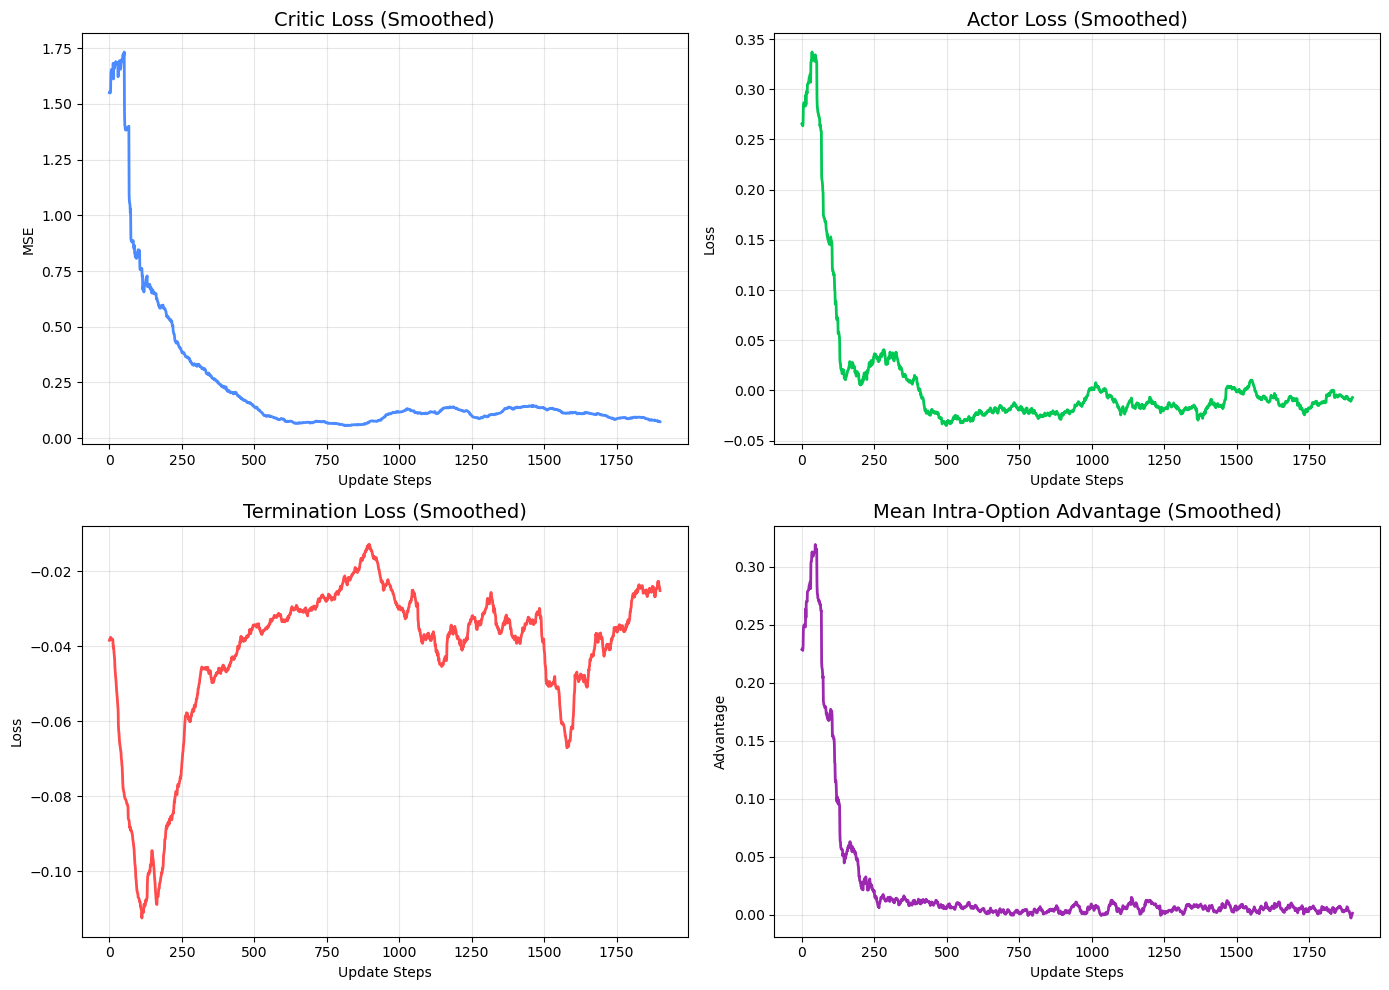

Actor Loss,▃█▃▂▃▅▄▄▃▁▄▃▂▄▂▂▂▂▂▃▃▂▂▃▂▃▃▂▃▁▂▂▃▃▃▃▃▃▂▃
Critic Loss,▄█▂▂▃▄▃▅▁▅▃▂▁▂▁▂▁▂▄▁▂▁▁▁▁▁▂▂▃▂▁▁▂▂▂▂▁▃▁▁
Mean Intra-Option Advantage,▃█▇▁▂▁▁▁▂▁▁▁▁▁▂▁▁▁▁▁▁▂▁▁▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▂
Termination Loss,▇▆▆▅▅▆▆▆▆▇▆▇▆▆▆▇▇▇▇███▆▇█▆▆▇▆▆▆▆▆▁█▇▆▆█▆
Actor Loss,0.01199
Critic Loss,0.03042
Mean Intra-Option Advantage,0.05755
Termination Loss,-0.07048


In [12]:
def smooth_curve(data, window=100):

    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')

def plot_training_curves(critic_loss, actor_loss, term_loss, adv, filename="plots/training_curves.png"):
    os.makedirs("plots", exist_ok=True)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    axes[0].plot(smooth_curve(critic_loss), color='#4B8BFF', linewidth=2)
    axes[0].set_title("Critic Loss (Smoothed)", fontsize=14)
    axes[0].set_xlabel("Update Steps")
    axes[0].set_ylabel("MSE")
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(smooth_curve(actor_loss), color='#00C853', linewidth=2)
    axes[1].set_title("Actor Loss (Smoothed)", fontsize=14)
    axes[1].set_xlabel("Update Steps")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(smooth_curve(term_loss), color='#FF4B4B', linewidth=2)
    axes[2].set_title("Termination Loss (Smoothed)", fontsize=14)
    axes[2].set_xlabel("Update Steps")
    axes[2].set_ylabel("Loss")
    axes[2].grid(True, alpha=0.3)
    
    axes[3].plot(smooth_curve(adv), color='#9C27B0', linewidth=2)
    axes[3].set_title("Mean Intra-Option Advantage (Smoothed)", fontsize=14)
    axes[3].set_xlabel("Update Steps")
    axes[3].set_ylabel("Advantage")
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    wandb.log({"Training/Smoothed_Curves": wandb.Image(filename)})
    plt.show()


print("plotting curves...")
plot_training_curves(critic_losses, actor_losses, termination_losses, advantages)


wandb.finish()

prep for visualization

In [13]:
os.makedirs("plots", exist_ok=True)

#initialize env and networks
device = 'cuda' if torch.cuda.is_available() else 'cpu'
env = FourRoomsEnv(bottleneck_rewards=True)
state_dim = env.observation_space.shape[0]
num_actions = env.action_space.n
num_options = 4

actor = ActorNetwork(num_actions, num_options, grid_size=env.grid_size)
critic = CriticNetwork(num_options, grid_size=env.grid_size)
agent = OptionCriticAgent(actor, critic, num_options, n_episodes=1, device=device)

#load trained weights
try:
    agent.load("trained_option_critic_11x11.pth")
    print("Agent weights loaded successfully for evaluation.")
except FileNotFoundError:
    print("Error: Could not find 'trained_option_critic_11x11.pth'. Make sure you ran the training loop and saved the agent!")

#weights for tracking
wandb.init(
    project="option-critic-four-rooms",
    name="evaluation-run",
    job_type="evaluation"
)

Agent loaded successfully from trained_option_critic_11x11.pth
Agent weights loaded successfully for evaluation.


visualization class.

Plotting and saving Trajectories...


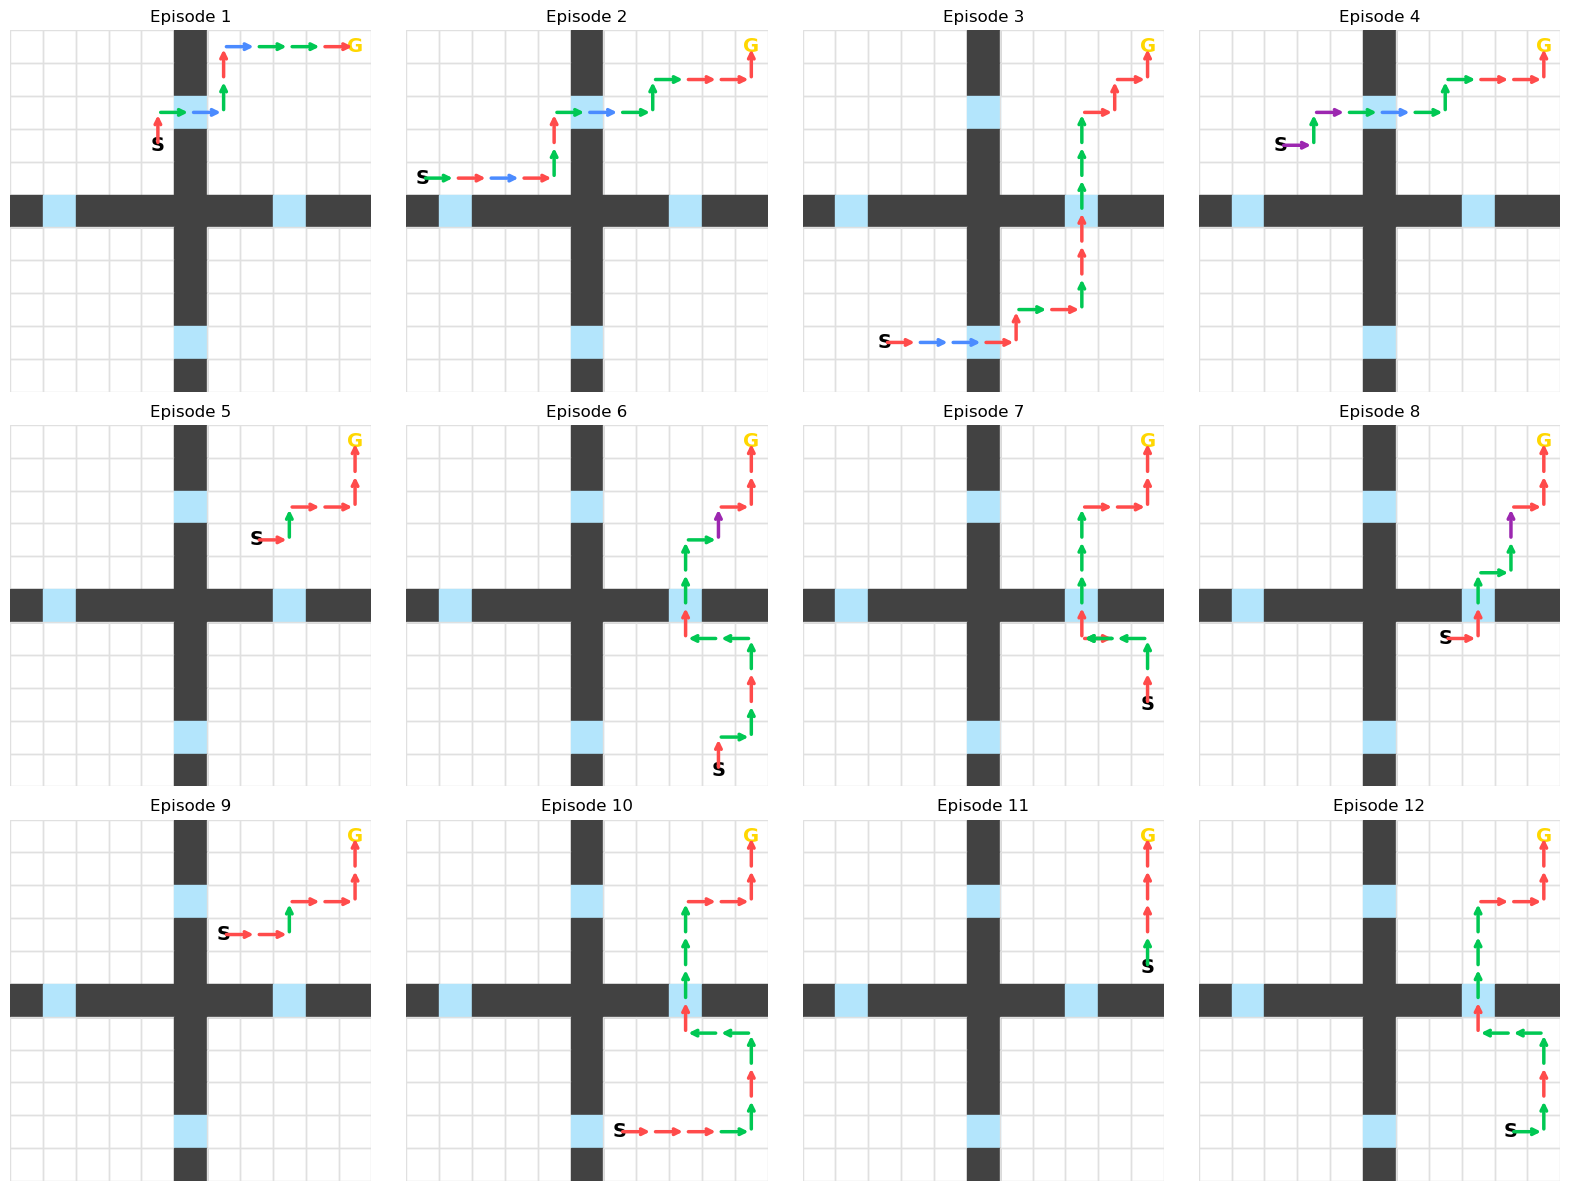

Sweeping state space and saving Heatmaps...


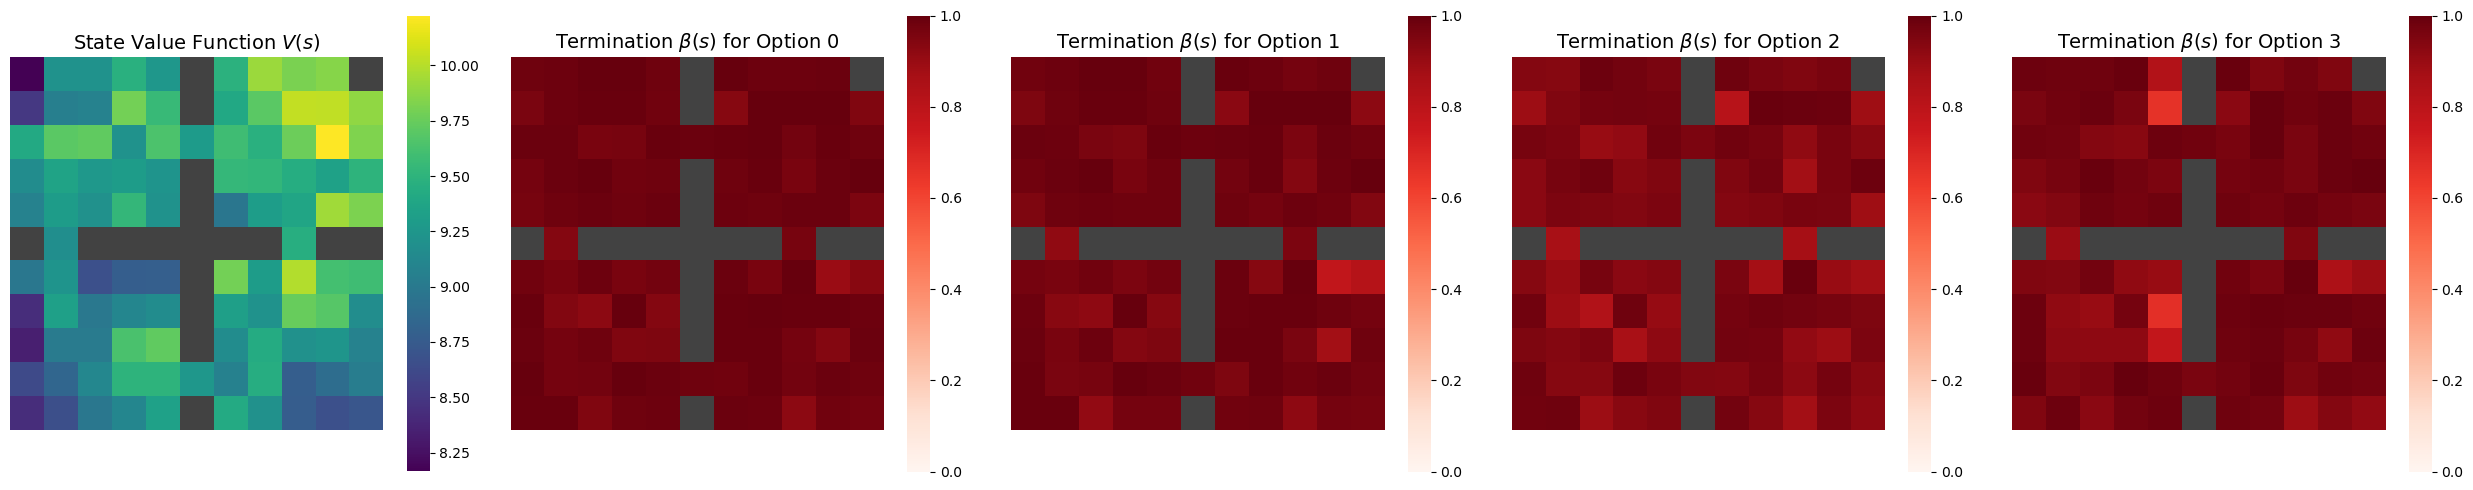

In [ ]:
class VisualEvaluator:
    def __init__(self, env, agent):
        self.env = env
        self.agent = agent
        self.num_options = agent.num_options
        self.trajectories_data = []
        
        #colors for options: Red, Blue, Green, Purple
        self.option_colors = ['#FF4B4B', '#4B8BFF', '#00C853', '#9C27B0']
        
    def collect_trajectories(self, num_episodes=12, max_steps=100):
        wandb.init()
        """Runs purely greedy episodes and stores the paths."""
        self.trajectories_data = []
        
        #pure exploitation
        original_epsilon = self.agent.epsilon
        self.agent.epsilon = 0.0 
        
        for _ in range(num_episodes):
            state_numpy, _ = self.env.reset()
            state_tensor = torch.FloatTensor(state_numpy).unsqueeze(0)
            
            #start greedily over options
            with torch.no_grad():
                q_vals = self.agent.critic(state_tensor.to(self.agent.device))
                current_option = torch.argmax(q_vals, dim=-1).item()
                
            start_state = self.env.current_state 
            trajectory = []
            
            step = 0
            done = False
            
            while not done and step < max_steps:
                r, c = self.env.current_state
                action = self.agent.get_action(state_tensor, current_option)
                trajectory.append((r, c, current_option, action))
                
                next_state_numpy, _, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                next_state_tensor = torch.FloatTensor(next_state_numpy).unsqueeze(0)
                
                #check termination greedily (if prob > 0.5)
                with torch.no_grad():
                    _, term_probs = self.agent.actor(next_state_tensor.to(self.agent.device))
                    beta = term_probs[0, current_option].item()
                    
                    if beta > 0.5:
                        q_vals_next = self.agent.critic(next_state_tensor.to(self.agent.device))
                        current_option = torch.argmax(q_vals_next, dim=-1).item()
                        
                state_tensor = next_state_tensor
                step += 1
                
            #log final resting state
            r, c = self.env.current_state
            trajectory.append((r, c, current_option, None))
            self.trajectories_data.append((trajectory, start_state, self.env.goal_state))
            
        self.agent.epsilon = original_epsilon

    def plot_trajectories(self, filename="plots/trajectories.png"):
        
        if not self.trajectories_data:
            print("No trajectory data to plot. Run collect_trajectories() first.")
            return
            
        num_plots = min(12, len(self.trajectories_data))
        cols = 4
        rows = (num_plots + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
        if num_plots == 1: axes = np.array([axes])
        axes = axes.flatten()
        
        for idx in range(num_plots):
            traj, start, goal = self.trajectories_data[idx]
            ax = axes[idx]
            
            ax.set_xlim(-0.5, self.env.grid_size - 0.5)
            ax.set_ylim(self.env.grid_size - 0.5, -0.5) 
            ax.set_aspect('equal')
            ax.axis('off')
            
            #draw grid and walls
            for r in range(self.env.grid_size):
                for c in range(self.env.grid_size):
                    if (r, c) in self.env.walls:
                        ax.add_patch(patches.Rectangle((c-0.5, r-0.5), 1, 1, color='#424242'))
                    elif (r, c) in self.env.doorway_list:
                        ax.add_patch(patches.Rectangle((c-0.5, r-0.5), 1, 1, color='#B3E5FC'))
                    else:
                        ax.add_patch(patches.Rectangle((c-0.5, r-0.5), 1, 1, fill=False, color='#E0E0E0'))
                            
            #draw start and goal
            ax.text(start[1], start[0], 'S', color='black', weight='bold', ha='center', va='center', fontsize=14)
            ax.text(goal[1], goal[0], 'G', color='#FFD700', weight='bold', ha='center', va='center', fontsize=14)
            
            #draw arrows
            for i in range(len(traj) - 1):
                r, c, opt, _ = traj[i]
                next_r, next_c, _, _ = traj[i+1]
                
                
                if r == next_r and c == next_c:
                    continue
                    
                ax.annotate("", xy=(next_c, next_r), xytext=(c, r),
                            arrowprops=dict(arrowstyle="->", color=self.option_colors[opt], lw=2.5))
                            
            ax.set_title(f"Episode {idx+1}", fontsize=12)
            
        
        for idx in range(num_plots, len(axes)):
            axes[idx].axis('off')
            
        plt.tight_layout()
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        wandb.log({"Evaluations/Trajectories": wandb.Image(filename)})
        plt.show()

    def plot_heatmaps(self, filename="plots/heatmaps.png"):
        
        grid_size = self.env.grid_size
        
        v_map = np.full((grid_size, grid_size), np.nan)
        beta_maps = [np.full((grid_size, grid_size), np.nan) for _ in range(self.num_options)]
        
        #sweep all valid states
        with torch.no_grad():
            for r in range(grid_size):
                for c in range(grid_size):
                    if (r, c) not in self.env.walls and (r, c) != self.env.goal_state:
                
                        obs = [float(r), float(c), 0.0, 0.0, 0.0, 0.0] 
                        state_tensor = torch.FloatTensor(obs).unsqueeze(0).to(self.agent.device)
                        
                        #get q-values and termination probs
                        q_vals = self.agent.critic(state_tensor)
                        _, term_probs = self.agent.actor(state_tensor)
                        
                        #V(s) = max_w Q(s, w)
                        v_map[r, c] = torch.max(q_vals).item()
                        
                        for opt in range(self.num_options):
                            beta_maps[opt][r, c] = term_probs[0, opt].item()

        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        
        #State Value Heatmap
        axes[0].set_facecolor('#424242') # Background color shows through NaNs
        sns.heatmap(v_map, ax=axes[0], cmap="viridis", cbar=True, square=True, 
                    xticklabels=False, yticklabels=False)
        axes[0].set_title("State Value Function $V(s)$", fontsize=14)
        
        #Termination Heatmaps
        for opt in range(self.num_options):
            axes[opt+1].set_facecolor('#424242') # Background color shows through NaNs
            sns.heatmap(beta_maps[opt], ax=axes[opt+1], cmap="Reds", cbar=True, square=True, 
                        xticklabels=False, yticklabels=False, vmin=0.0, vmax=1.0)
            axes[opt+1].set_title(f"Termination $\\beta(s)$ for Option {opt}", fontsize=14)
            
        plt.tight_layout()
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        wandb.log({"Evaluations/Heatmaps": wandb.Image(filename)})
        plt.show()


#for saving visuals.
visualizer = VisualEvaluator(env, agent)

print("Collecting strict greedy trajectories...")
visualizer.collect_trajectories(num_episodes=12)

print("Plotting and saving Trajectories...")
visualizer.plot_trajectories(filename="plots/trajectories.png")

print("Sweeping state space and saving Heatmaps...")
visualizer.plot_heatmaps(filename="plots/heatmaps.png")

wandb.finish() 